# Data Fetching


<b> Objective: </b>
Organize data from GEUS into tabular form

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>


### Imports

In [1]:
import pandas as pd
from dataclasses import dataclass
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import numpy as np
import matplotlib.pyplot as plt

from GreenlandUtils import PlotSamplesOnMap, Printable, DFStats, MostCommonElements, displaySplit, verifyStratification

SEED = 42

### Setup

In [2]:
DATA_TYPE = "Whole Rock"
MERGE_TYPE = "Mean Merge"

rockDF = pd.read_csv("Data/whole-rock.csv", sep=";")

In [3]:
metaCols = ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr']
DFStats(rockDF, metaCols)

Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 3981.70it/s]

============================== Quantities ==============================
Rows:                          26068
Samples:                       6957


============================== Structure ==============================
Columns:                       88
Column Names:                  ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr', 'SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3 wt%', 'Fe2O3 wt%.1', 'FeO wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'C wt%', 'Li ppm', 'Be ppm', 'B ppm', 'S ppm', 'Cl wt%', 'Sc ppm', 'V ppm', 'Cr ppm', 'Co ppm', 'Ni ppm', 'Cu ppm', 'Zn ppm', 'Ga ppm', 'Ge ppm', 'As ppm', 'Se ppm', 'Br ppm', 'Rb ppm', 'Sr ppm', 'Y ppm', 'Zr ppm', 'Nb ppm', 'Mo ppm', 'Ru ppb', 'Rh ppb', 'Pd ppb', 'Ag ppm', 'Cd ppm', 'In ppm', 'Sn ppm', 'Sb ppm', 'Te ppm', 'I ppm', 'Cs ppm', 'Ba ppm', 'La ppm', 'C

### Merging Samples

In [4]:
def MergeSamples(df : pd.DataFrame, metaCols : list) -> pd.DataFrame:
    
    elementCols = [col for col in df.columns if col not in metaCols]
    
    BDL_filtered = df.copy()
    BDL_filtered[elementCols] = BDL_filtered[elementCols].mask(lambda x : x <=0)

    elements_merged = BDL_filtered.groupby('Sample number').agg({col: 'median' for col in BDL_filtered.columns if col not in metaCols}).reset_index()
    elements_merged[elementCols] = np.log10(elements_merged[elementCols])
   
    metaData_merged = BDL_filtered[metaCols].drop_duplicates(subset=['Sample number'])
    df_merged = pd.merge(metaData_merged, elements_merged, on='Sample number', how='inner')
    
    return df_merged

def saveDF(df: pd.DataFrame, path: str, baseName: str):
    df.to_csv(f"{path}{baseName}.csv", sep=";", index=False)

mergedDF = MergeSamples(rockDF, metaCols)
DFStats(mergedDF, metaCols)


Analyzing Elements: 100%|██████████| 76/76 [00:00<00:00, 5858.29it/s]

============================== Quantities ==============================
Rows:                          6957
Samples:                       6957


============================== Structure ==============================
Columns:                       88
Column Names:                  ['Sample number', 'Sampling year', 'Rock description', 'Link to report', 'Collector', 'Batch', 'Longitude', 'Latitude', 'Laboratory', 'Treatment year', 'Sample preparation abbr', 'Analytical method abbr', 'SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3 wt%', 'Fe2O3 wt%.1', 'FeO wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'C wt%', 'Li ppm', 'Be ppm', 'B ppm', 'S ppm', 'Cl wt%', 'Sc ppm', 'V ppm', 'Cr ppm', 'Co ppm', 'Ni ppm', 'Cu ppm', 'Zn ppm', 'Ga ppm', 'Ge ppm', 'As ppm', 'Se ppm', 'Br ppm', 'Rb ppm', 'Sr ppm', 'Y ppm', 'Zr ppm', 'Nb ppm', 'Mo ppm', 'Ru ppb', 'Rh ppb', 'Pd ppb', 'Ag ppm', 'Cd ppm', 'In ppm', 'Sn ppm', 'Sb ppm', 'Te ppm', 'I ppm', 'Cs ppm', 'Ba ppm', 'La ppm', 'Ce

### Geophysical Features

Geochemical neighbours are only available where somebody has already sampled. Geophysical
grids are measured everywhere, so they are what replaces the neighbourhood once we move to
unexplored ground.

Only grids with **full Greenland coverage** are used, so the same columns can be attached to
any future sample set (stream sediment, heavy minerals) without changing the pipeline.

| column | source | grid | licence |
|---|---|---|---|
| `geo_magnetic_anomaly nT` | GREENMAG `doi:10.22008/FK2/LQN5YJ` | 400 m, native UTM 24N | CC-BY 4.0 |
| `geo_heat_flow mW/m2` | Greenland Geothermal Heat Flow `doi:10.22008/FK2/F9P03L` | ~0.4 deg (~25 km), lon/lat | CC0 |
| `geo_depth_to_moho km` | Depth to Moho `doi:10.22008/FK2/TG7OQU` | ~0.5 km spacing, lon/lat | CC-BY 4.0 |

What each one measures, briefly:

* **magnetic anomaly** - how far the local magnetic field departs from the reference field.
  Magnetite-rich mafic and ultramafic rock reads high, granite and sediment barely register,
  so it tracks how mafic the rock underfoot is.
* **heat flow** - how much heat escapes the ground. Driven by tectonic setting and by decay
  of U, Th and K in the crust, so it loosely tracks those elements.
* **depth to Moho** - thickness of the crust above the mantle. Thin under rifted margins,
  thick under old craton, so it separates tectonic settings that host different deposits.
  It varies over hundreds of km, so treat it as a regional field rather than a local one.

Coverage was checked over Greenland as a whole rather than over the samples at hand, so the
same columns can be attached to any future sample set. GREENMAG has 1.5% missing cells inside
its envelope; the other two have none. Grids that failed this test are left out: the NAG-TEC
gravity, crustal thickness and sediment thickness products are North Atlantic compilations
whose point density collapses west of 50 deg W, hundreds of km from most Greenland samples.

Values stay NaN where a grid has no data, which the boosted models read natively.

Download once into `Data/Geophysics/` (167 MB + 85 MB + 0.2 MB):

```
https://dataverse.geus.dk/api/access/datafile/91476   GREENMAG_magnetic_anomaly.flt
https://dataverse.geus.dk/api/access/datafile/91477   GREENMAG_magnetic_anomaly.hdr
https://dataverse.geus.dk/api/access/datafile/19155   GeothermalHeatFlow.xyz
https://dataverse.geus.dk/api/access/datafile/32409   DepthToMoho.xyz
```

In [7]:
from sklearn.neighbors import NearestNeighbors
from GreenlandUtils import lonlatToUTM24N

GEOPHYSICS_PATH = "Data/Geophysics/"
GEO_PREFIX = "geo_"


def ReadESRIHeader(path: str) -> dict:
    with open(path, "r") as f:
        entries = [line.split() for line in f if line.strip()]

    header = {}
    for key, value in entries:
        header[key.lower()] = int(value) if value.lstrip("-").isdigit() else value
    return header


def SampleESRIGrid(df: pd.DataFrame, path: str, baseName: str) -> np.ndarray:
    header = ReadESRIHeader(f"{path}{baseName}.hdr")
    ncols, nrows = header["ncols"], header["nrows"]
    cell, nodata = header["cellsize"], header["nodata_value"]

    grid = np.memmap(f"{path}{baseName}.flt", dtype="<f4", mode="r", shape=(nrows, ncols))

    x, y = lonlatToUTM24N(df["Longitude"].to_numpy(float), df["Latitude"].to_numpy(float))

    col = np.floor((x - header["xllcorner"]) / cell).astype(int)
    row = np.floor((header["yllcorner"] + nrows * cell - y) / cell).astype(int)

    inside = (col >= 0) & (col < ncols) & (row >= 0) & (row < nrows)

    values = np.full(len(df), np.nan)
    values[inside] = grid[row[inside], col[inside]]
    values[values == nodata] = np.nan

    return values


def SampleXYZGrid(df: pd.DataFrame, path: str, baseName: str, valueCol: int = 2) -> np.ndarray:
    rows = []
    with open(f"{path}{baseName}.xyz", "r") as f:
        for line in f:
            if line.startswith("%") or not line.strip():
                continue
            rows.append(line.split())

    grid = np.array([[float(v) for v in row[:valueCol + 1]] for row in rows])

    tree = NearestNeighbors(n_neighbors=1).fit(grid[:, :2])
    _, positions = tree.kneighbors(df[["Longitude", "Latitude"]].to_numpy(float))

    return grid[positions[:, 0], valueCol]


def AddGeophysics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df[f"{GEO_PREFIX}magnetic_anomaly nT"] = SampleESRIGrid(df, GEOPHYSICS_PATH, "GREENMAG_magnetic_anomaly")
    df[f"{GEO_PREFIX}heat_flow mW/m2"] = SampleXYZGrid(df, GEOPHYSICS_PATH, "GeothermalHeatFlow")
    df[f"{GEO_PREFIX}depth_to_moho km"] = SampleXYZGrid(df, GEOPHYSICS_PATH, "DepthToMoho")

    return df


mergedDF = AddGeophysics(mergedDF)

geoCols = [col for col in mergedDF.columns if col.startswith(GEO_PREFIX)]

printable = Printable()
printable.title("Geophysical Features")
for col in geoCols:
    values = mergedDF[col]
    printable.add(col, f"valid: {values.notna().sum():>5}/{len(mergedDF)} ({values.notna().mean():.1%})  range: {values.min():>8.1f} to {values.max():<8.1f}")
printable.flush()

============================== Geophysical Features ==============================
geo_magnetic_anomaly nT:   valid:  6957/6957 (100.0%)  range:   -472.1 to 840.2   
geo_heat_flow mW/m2:       valid:  6957/6957 (100.0%)  range:     32.9 to 117.7   
geo_depth_to_moho km:      valid:  6957/6957 (100.0%)  range:     27.7 to 46.6    


<Axes: title={'left': 'Depth to Moho at sample locations (km)  (6,957 samples)'}, xlabel='Longitude (EPSG:32624)', ylabel='Latitude (EPSG:32624)'>

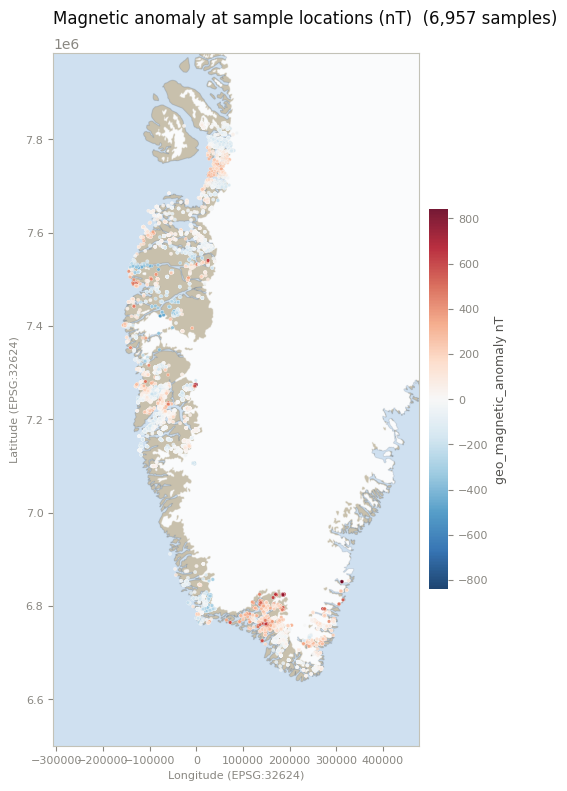

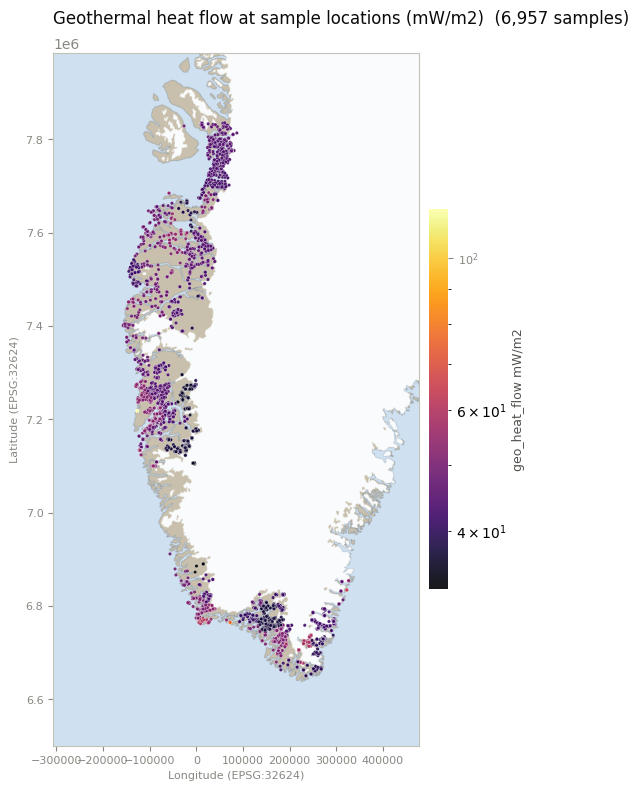

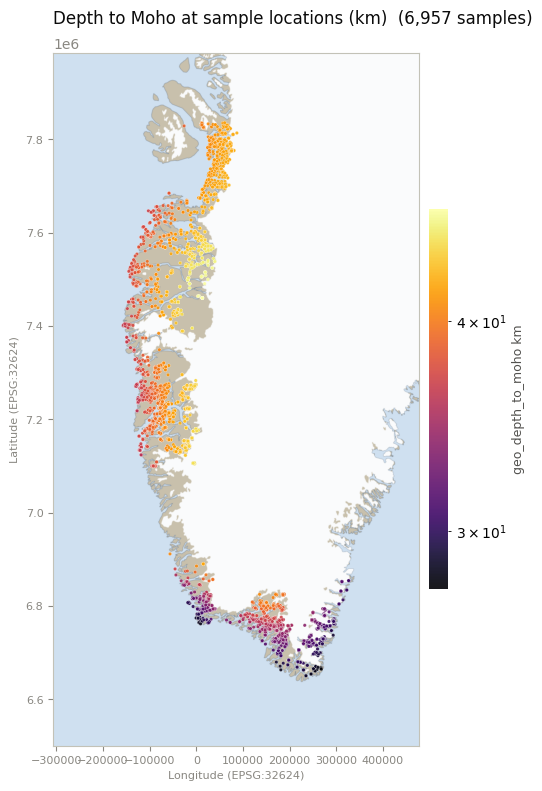

In [8]:
#Magnetic anomaly is signed, so negatives are kept and the colour scale is centred on zero
PlotSamplesOnMap(mergedDF, element=f"{GEO_PREFIX}magnetic_anomaly nT", title="Magnetic anomaly at sample locations (nT)", cmap="RdBu_r", signed=True)
PlotSamplesOnMap(mergedDF, element=f"{GEO_PREFIX}heat_flow mW/m2", title="Geothermal heat flow at sample locations (mW/m2)", cmap="inferno")
PlotSamplesOnMap(mergedDF, element=f"{GEO_PREFIX}depth_to_moho km", title="Depth to Moho at sample locations (km)", cmap="inferno")

##### Geophysics vs Geochemistry

Which elements does each geophysical field actually track? Correlations are computed on the
log10 concentrations already in the frame, pairwise so that an element missing from a sample
only costs that pair rather than the whole row.

Spearman is used alongside Pearson: Pearson catches straight-line relationships, Spearman
catches any monotone one, so a large gap between them means the relationship is real but
curved. Only elements with enough paired samples are kept, since a correlation over a handful
of points is noise.

The map coordinates are included as two extra rows. A geophysical field that correlates with
an element no more strongly than plain northing does is not contributing much beyond position.

In [9]:
from scipy.stats import pearsonr, spearmanr

MIN_PAIRS = 100


def CorrelateGeophysics(df: pd.DataFrame, geoCols: list[str], elementCols: list[str], minPairs: int = MIN_PAIRS) -> pd.DataFrame:

    #Northing and easting ride along as a reference: a field that beats neither is just position
    x, y = lonlatToUTM24N(df["Longitude"].to_numpy(float), df["Latitude"].to_numpy(float))
    predictors = {col: df[col].to_numpy(float) for col in geoCols}
    predictors["(easting)"] = x
    predictors["(northing)"] = y

    rows = []
    for element in elementCols:
        target = df[element].to_numpy(float)

        for name, values in predictors.items():
            paired = np.isfinite(target) & np.isfinite(values)
            if paired.sum() < minPairs:
                continue

            rows.append({
                "element": element,
                "predictor": name,
                "n": int(paired.sum()),
                "pearson": pearsonr(values[paired], target[paired])[0],
                "spearman": spearmanr(values[paired], target[paired])[0],
            })

    return pd.DataFrame(rows)


elementCols = [col for col in mergedDF.columns if col not in metaCols and not col.startswith(GEO_PREFIX)]

correlations = CorrelateGeophysics(mergedDF, geoCols, elementCols)

printable = Printable()
printable.title("Strongest Element Correlations")
for name in geoCols:
    subset = correlations[correlations["predictor"] == name]
    subset = subset.reindex(subset["spearman"].abs().sort_values(ascending=False).index)

    printable.add(name, "")
    for _, row in subset.head(8).iterrows():
        printable.add(f"   {row['element']}", f"spearman {row['spearman']:>+6.3f}   pearson {row['pearson']:>+6.3f}   n={int(row['n'])}")
    printable.rest()

printable.title("Position, For Reference")
for name in ["(easting)", "(northing)"]:
    subset = correlations[correlations["predictor"] == name]
    subset = subset.reindex(subset["spearman"].abs().sort_values(ascending=False).index)
    best = subset.iloc[0]
    printable.add(name, f"strongest: {best['element']} at spearman {best['spearman']:>+6.3f}   "
                        f"median |spearman| {subset['spearman'].abs().median():.3f}")
printable.flush()

============================ Strongest Element Correlations ============================
geo_magnetic_anomaly nT:   
   C wt%:                  spearman +0.481   pearson +0.596   n=101
   U ppm:                  spearman +0.284   pearson +0.283   n=3227
   Zr ppm:                 spearman +0.207   pearson +0.204   n=3502
   Nb ppm:                 spearman +0.206   pearson +0.204   n=1978
   Co ppm:                 spearman -0.197   pearson -0.193   n=4378
   Se ppm:                 spearman -0.193   pearson -0.197   n=305
   Tm ppm:                 spearman +0.181   pearson +0.178   n=412
   Ho ppm:                 spearman +0.177   pearson +0.132   n=433


geo_heat_flow mW/m2:       
   C wt%:                  spearman -0.688   pearson -0.780   n=101
   Sn ppm:                 spearman +0.503   pearson +0.497   n=443
   Se ppm:                 spearman +0.280   pearson +0.264   n=305
   Br ppm:                 spearman -0.268   pearson -0.272   n=715
   Ge ppm:                 spearm

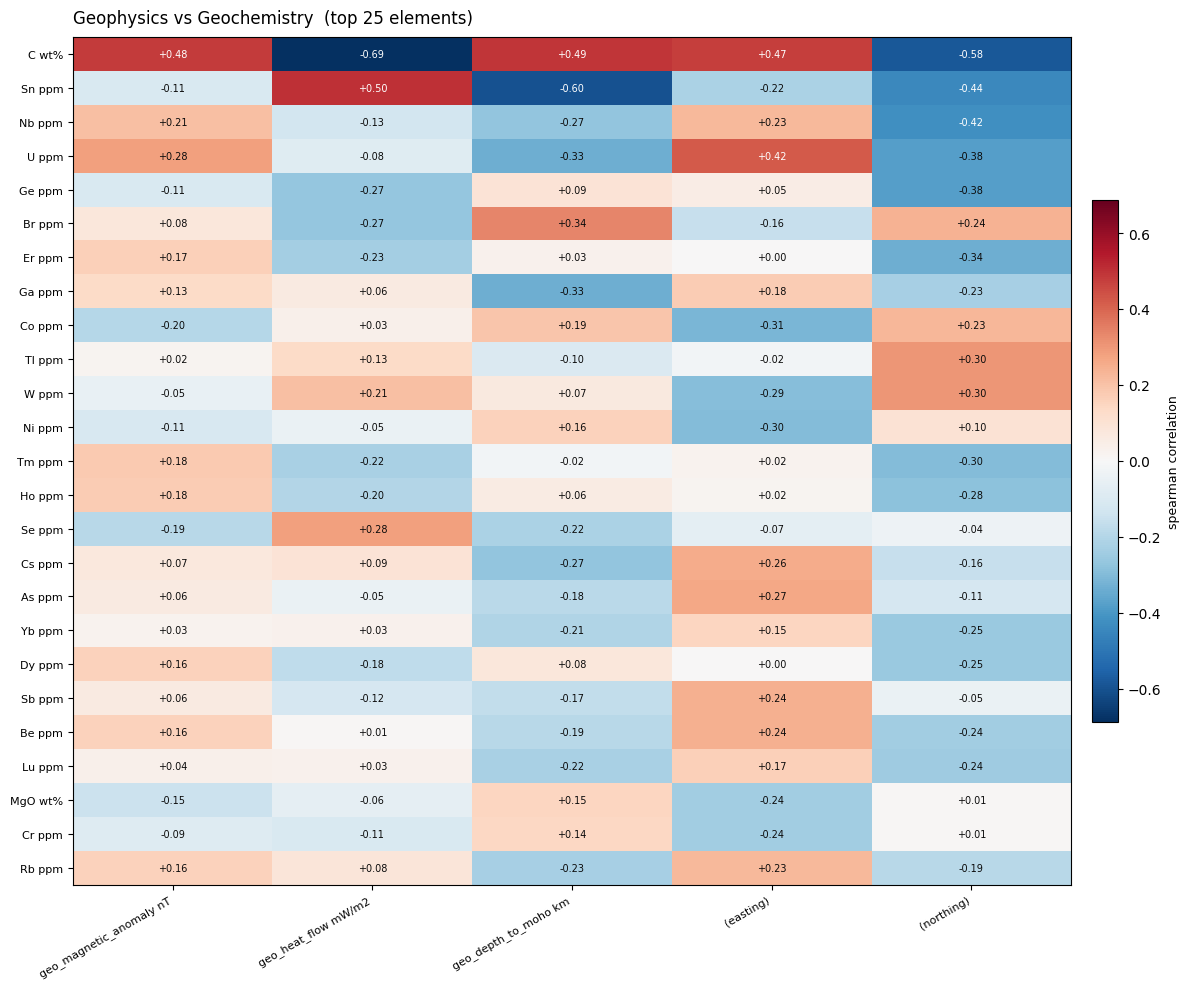

In [10]:
def DisplayCorrelationHeatmap(correlations: pd.DataFrame, predictors: list[str], metric: str = "spearman", topN: int = 25, title: str = "Geophysics vs Geochemistry"):

    grid = correlations.pivot(index="element", columns="predictor", values=metric)
    grid = grid.reindex(columns=[col for col in predictors if col in grid.columns])
    grid = grid.dropna(how="all")

    #Rank by the strongest correlation an element reaches with any field, so the plot stays readable
    order = grid.abs().max(axis=1).sort_values(ascending=False).index[:topN]
    grid = grid.loc[order]

    fig, ax = plt.subplots(figsize=(1.6 * len(grid.columns) + 4, 0.32 * len(grid) + 2))

    limit = float(np.nanmax(np.abs(grid.to_numpy())))
    image = ax.imshow(grid.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")

    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(grid)))
    ax.set_yticklabels(grid.index, fontsize=8)

    for i in range(len(grid)):
        for j in range(len(grid.columns)):
            value = grid.to_numpy()[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=7,
                        color="white" if abs(value) > 0.6 * limit else PRIMARY)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    colorbar.set_label(f"{metric} correlation", fontsize=9)

    ax.set_title(f"{title}  (top {len(grid)} elements)", fontsize=12, pad=10, loc="left")

    plt.tight_layout()
    plt.show()


from GreenlandUtils import PRIMARY

DisplayCorrelationHeatmap(correlations, geoCols + ["(easting)", "(northing)"], metric="spearman")

In [11]:
saveDF(mergedDF, f"Data/{DATA_TYPE}/{MERGE_TYPE}/", "Data")

print(f"Saved {len(mergedDF)} samples, {len(mergedDF.columns)} columns ({len(geoCols)} geophysical)")

Saved 6957 samples, 91 columns (3 geophysical)


### Splitting & K-Fold

In [10]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import json
from GreenlandUtils import Split


def splitDF(df: pd.DataFrame, ratios: list[float]=[0.8,0.1,0.1], method: str="random", **kwargs) -> Split:
    assert abs(sum(ratios) - 1.0) < 1e-9, "Ratios don't add up to 1.0"
    assert method in ["random", "kmeans"], "Method must be 'random' or 'kmeans'"
    
    train_ratio, val_ratio, test_ratio = ratios
    
    if method == "random":
        train_df, temp_df = train_test_split(df, train_size=train_ratio, test_size=test_ratio+val_ratio, random_state=SEED, shuffle=True)
        val_df, test_df = train_test_split(temp_df, test_size=test_ratio/(test_ratio+val_ratio), random_state=SEED, shuffle=True)
        return Split({ "train": train_df, "val": val_df, "test": test_df })


def splitKFold(df: pd.DataFrame, method: str="random", kfold: int=5, **kwargs) -> list[Split]:
    assert method in ["random", "kmeans"], "Method must be 'random' or 'kmeans'"

    if method == "random":
        splits = []
        for trainval_idx, test_idx in KFold(n_splits=kfold, shuffle=True, random_state=SEED).split(df):
            train_df, test_df = df.iloc[trainval_idx], df.iloc[test_idx]
            splits.append(Split({ "train": train_df, "val": pd.DataFrame(), "test": test_df }))
        return splits


def saveSplit(split: Split, baseName:str, path: str):
    json_result = {split_name: df.index.tolist() for split_name, df in split.data.items()}
    with open(f"{path}{baseName}.split", "w") as f:
        json.dump(json_result, f, indent=4)
  
def saveKFold(splits: list[Split], baseName:str, path: str):
    result = {i : {split_name: df.index.tolist() for split_name, df in split.data.items()} for i, split in enumerate(splits)}
    with open(f"{path}{baseName}.kfold", "w") as f:
        json.dump(result, f, indent=4)

#['Zn ppm', 'CaO wt%', 'Sr ppm', 'Ni ppm', 'Cr ppm', 'Al2O3 wt%', 'Cu ppm', 'Fe2O3 wt%', 'V ppm', 'Ba ppm']

split = splitDF(mergedDF, ratios=[0.8, 0.1, 0.1], method="random")
verifyStratification(split.data, "Cr ppm")

kfold_splits = splitKFold(mergedDF, method="random", kfold=5)

saveKFold(kfold_splits, "5-Fold", f"Data/{DATA_TYPE}/{MERGE_TYPE}/")
saveSplit(split, "Holdout", f"Data/{DATA_TYPE}/{MERGE_TYPE}/")

def SplitStats(split: Split):
    printable = Printable()
    printable.add("Train", f"{len(split.data['train'])} ({len(split.data['train'])/len(mergedDF)*100:.2f}%)")
    printable.add("Validation", f"{len(split.data['val'])} ({len(split.data['val'])/len(mergedDF)*100:.2f}%)")
    printable.add("Test", f"{len(split.data['test'])} ({len(split.data['test'])/len(mergedDF)*100:.2f}%)")
    printable.rest()
    printable.pretty()

for i, kfold_split in enumerate(kfold_splits):
    SplitStats(kfold_split)

========= Stratification Verification for Cr ppm =========
Total Samples:      6957
Train Ratio:        0.80 (0.63), Mean: 2.02
Validation Ratio:   0.10 (0.08), Mean: 2.04
Test Ratio:         0.10 (0.08), Mean: 2.06


Train:        5565 (79.99%)
Validation:   0 (0.00%)
Test:         1392 (20.01%)


Train:        5565 (79.99%)
Validation:   0 (0.00%)
Test:         1392 (20.01%)


Train:        5566 (80.01%)
Validation:   0 (0.00%)
Test:         1391 (19.99%)


Train:        5566 (80.01%)
Validation:   0 (0.00%)
Test:         1391 (19.99%)


Train:        5566 (80.01%)
Validation:   0 (0.00%)
Test:         1391 (19.99%)




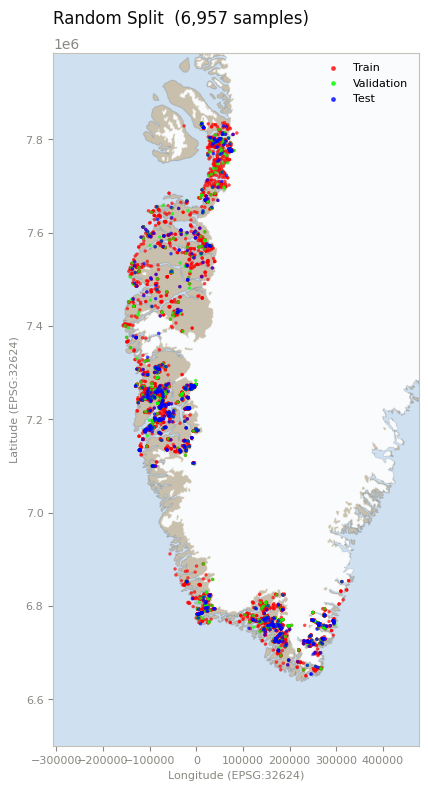

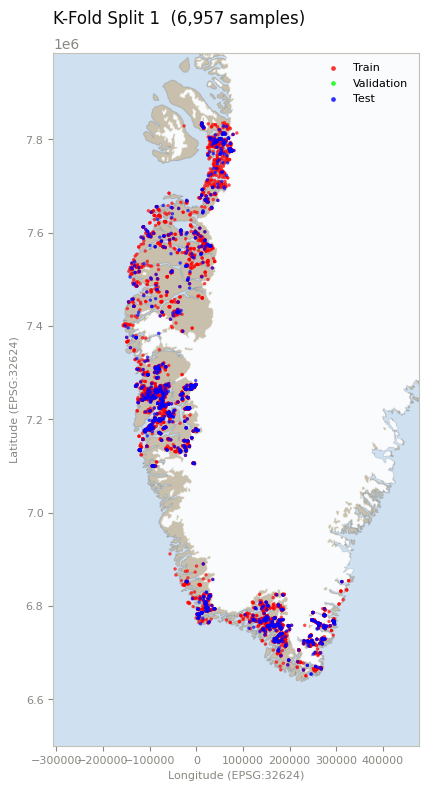

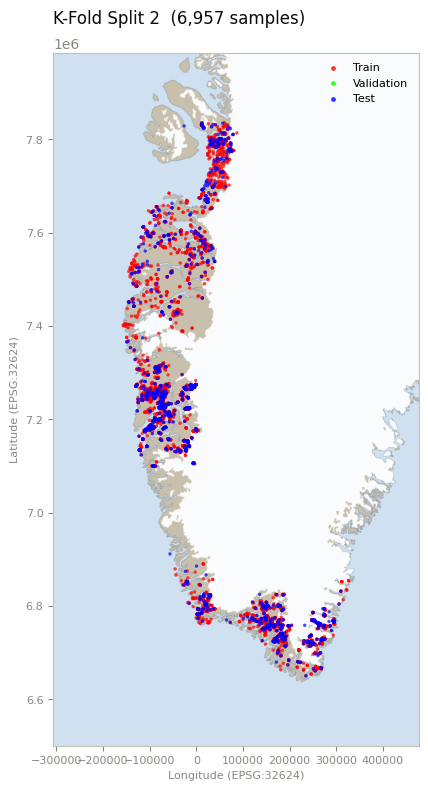

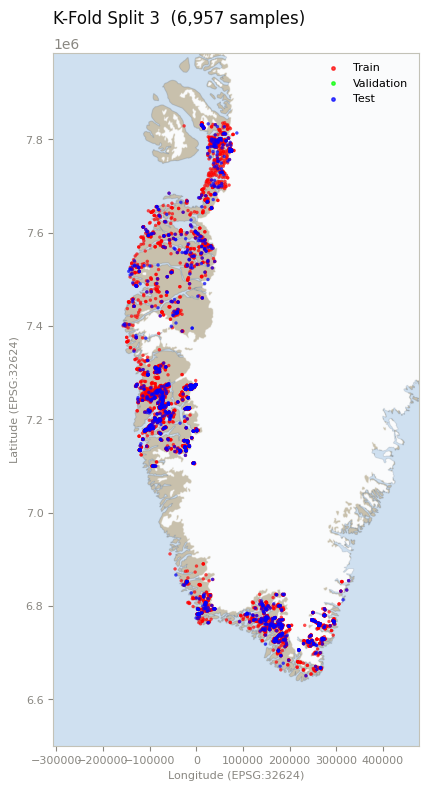

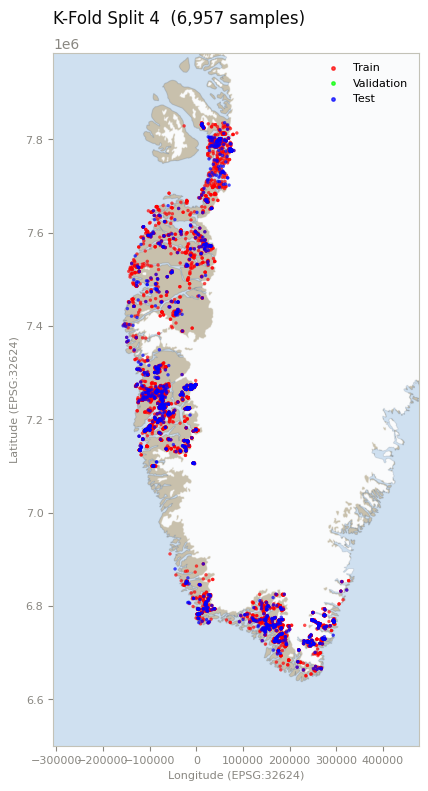

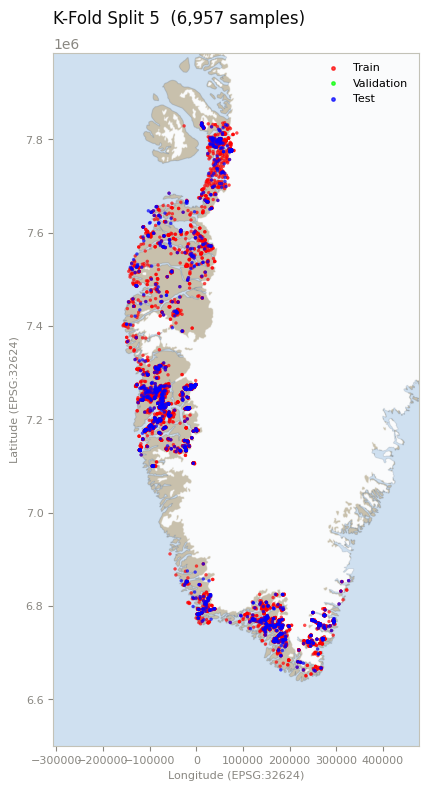

In [8]:
displaySplit(split.data, title="Random Split")

for i, kfold_split in enumerate(kfold_splits):
    displaySplit(kfold_split.data, title=f"K-Fold Split {i+1}")

### Nearest Neighbours

In [8]:
dfKNN = pd.read_csv(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Data_KNN.csv", sep=";")

##### Building Neighbour Mapping

Takes a dataframe with location coordinates and a split and creates the NN mapping (only with train context)

In [12]:
from GreenlandUtils import lonlatToUTM24N

def ProjectedCoords(df: pd.DataFrame, lonCol: str = "Longitude", latCol: str = "Latitude") -> np.ndarray:
    x, y = lonlatToUTM24N(df[lonCol].to_numpy(dtype=float), df[latCol].to_numpy(dtype=float))
    return np.column_stack([x, y])


def NearestNeighbours(context: pd.DataFrame, entry: pd.Series, n: int):
    
    #Get projected coords version
    contextCoords = ProjectedCoords(context, lonCol="Longitude", latCol="Latitude")
    entryCoords = ProjectedCoords(entry.to_frame().T, lonCol="Longitude", latCol="Latitude")[0]

    #Calculate distances
    distances = np.linalg.norm(contextCoords - entryCoords, axis=1)

    #Exclude self
    distances[context.index == entry.name] = np.inf

    #Get nearest neighbours
    nearest_indices = np.argsort(distances)[:n]
    return context.iloc[nearest_indices]        
        
def BuildNearestNeighboursData(df: pd.DataFrame, split : Split, n:int=20, path:str="Data/{DATA_TYPE}/{MERGE_TYPE}/", baseName:str="NearestNeighbours"):
    idx = []
    
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Building Nearest Neighbours Data"):
        nn = NearestNeighbours(split.data["train"], row, n)
        idx.append((i, nn.index.tolist()))
        
    with open(f"{path}{baseName}.json", "w") as f:
        json.dump(dict(idx), f, indent=4)
        

DATA_TYPE = "Whole Rock"
MERGE_TYPE = "Mean Merge"
BuildNearestNeighboursData(mergedDF, split, n=20, path=f"Data/{DATA_TYPE}/{MERGE_TYPE}/")

Building Nearest Neighbours Data: 100%|██████████| 6957/6957 [00:26<00:00, 261.99it/s]


In [13]:
#K-Fold Nearest Neighbours
for i, kfold_split in enumerate(kfold_splits):
    BuildNearestNeighboursData(dfKNN, kfold_split, n=20, path=f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", baseName=f"NearestNeighbours-Fold-{i+1}")

Building Nearest Neighbours Data: 100%|██████████| 6957/6957 [00:44<00:00, 158.11it/s]


##### Create Nearest Neighbour Data

Takes a Dataframe, a split and a NN map and creates a new Dataframe with the information of the elements of the neighbours

In [17]:
from tqdm.auto import tqdm


def NearestNeighboursEntries(df: pd.DataFrame, entry: pd.Series, n: int, nns: dict[int, list[int]]) -> pd.DataFrame:
    if entry.name not in nns:
        return
    
    nearest_idx = nns[entry.name][:n]
    nearest_entries = df.loc[nearest_idx]
    return nearest_entries

def ReadNearestNeighbours(path: str, baseName: str) -> dict[int, list[int]]:
    with open(f"{path}{baseName}.json", "r") as f:
        json_result = json.load(f)
    return {int(k): v for k, v in json_result.items()}

tqdm.pandas(desc="Processing Rows")

#Entry Builder
def BuildKNNFullEntry(entry: pd.Series, df: pd.DataFrame, n:int, elementCols: list[str], local_nns: dict[int, list[int]], verbose: bool = False) -> pd.Series:
    #df is the context only
    nearestNeighbours = NearestNeighboursEntries(df, entry, n, local_nns)
    
    entry_copy = entry.copy()
    
    total = len(elementCols) * len(nearestNeighbours)
    pbar = tqdm(total=total, desc="Processing KNN", disable=not verbose)

    for element in elementCols:
        mean_value = nearestNeighbours[element].mean()
        entry_copy[f"{n}-KNN_{element}_mean"] = mean_value

        for i in range(len(nearestNeighbours)):
            entry_copy[f"{i+1}of{n}-KNN_{element}"] = nearestNeighbours.iloc[i][element]
            pbar.update(1)

    pbar.close()
    return entry_copy


In [18]:
# dfKNN = df.progress_apply(lambda entry: BuildKNNFullEntry(entry, df, n=5, elementCols=elementCols, verbose=False), axis=1)
# dfKNN.to_csv(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Data_KNN.csv", sep=";", index=False)

elementCols = [col for col in mergedDF.columns if col not in metaCols]

for i, kfold_split in enumerate(kfold_splits):
    kfold_nns = ReadNearestNeighbours(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/", f"NearestNeighbours-Fold-{i+1}")
    dfKNN_fold = mergedDF.progress_apply(lambda entry: BuildKNNFullEntry(entry, kfold_split.data["train"], n=5, elementCols=elementCols, verbose=False, local_nns=kfold_nns), axis=1)
    dfKNN_fold.to_csv(f"Data/{DATA_TYPE}/{MERGE_TYPE}/Folds/Data_KNN_Fold_{i+1}.csv", sep=";", index=False)

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]

Processing Rows:   0%|          | 0/6957 [00:00<?, ?it/s]